<a href="https://colab.research.google.com/github/wawaelenti/Machine-Learning/blob/main/KMeans_Perbandingan_Distance_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📐 1. Formulasi Matematis & Perbandingan Metrik Jarak

Tiga metrik yang dibandingkan adalah:

| Metrik | Rumus | Implementasi |
| --- | --- | --- |
| Euclidean | $d(x,y)=\sqrt{\sum_i(x_i-y_i)^2}$ | K-Means dengan centroid rata-rata |
| Manhattan | $d(x,y)=\sum_i|x_i-y_i|$ | K-Medians dengan centroid median |
| Cosine | $d(x,y)=1-\frac{x\cdot y}{\lVert x\rVert_2\lVert y\rVert_2}$ | K-Means pada fitur yang dinormalisasi L2 |

Seluruh model menggunakan baris yang sama dan preprocessing yang sama
sampai StandardScaler. Varian Cosine melanjutkan normalisasi L2 dan memakai
cosine similarity untuk analisis, serta cosine distance untuk Silhouette.
Centroid model Cosine berupa rata-rata hasil `KMeans`.

Evaluasi mempertahankan Silhouette per metrik, Silhouette Euclidean pada
`X_scaled`, ARI, NMI, waktu fit, dan penggunaan memori. Label `status`
dipakai untuk ARI/NMI setelah clustering. PCA memproyeksikan hasil visualisasi.

In [ ]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

from kneed import KneeLocator
import time, os, gc, threading, tracemalloc
import psutil


In [ ]:
# =======================================================================
# 2. DATASET & PREPROCESSING BERSAMA
# =======================================================================
FILE = 'dataset_B_05_2020 (1).csv'
df = pd.read_csv(FILE)

print('Shape dataset:', df.shape)
print('Jumlah data:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
display(df.head(3))

# Metadata dan label asli disimpan terpisah dari fitur clustering.
urls = df['url'].copy()
y_true = df['status'].copy()
labels = y_true.copy()
X = df.drop(columns=['url', 'status']).select_dtypes(include=np.number)
print('Shape fitur numerik:', X.shape)

# Imputasi median, penghapusan fitur konstan, lalu StandardScaler.
print('Missing value sebelum imputasi:', int(X.isna().sum().sum()))
X = X.fillna(X.median())
print('Missing value setelah imputasi:', int(X.isna().sum().sum()))

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
removed_features = X.columns[~selector.get_support()]
X_selected = pd.DataFrame(X_sel, columns=selected_features, index=X.index)
print('Fitur konstan yang dihapus:', list(removed_features))
print('Shape setelah seleksi fitur:', X_selected.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
df_after = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)
print('Shape setelah StandardScaler:', X_scaled.shape)
display(df_after.head(3))

# Normalisasi L2 digunakan oleh varian K-Means Cosine.
X_cosine = normalize(X_scaled, norm='l2')
print('Shape setelah normalisasi L2:', X_cosine.shape)


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


Shape fitur numerik: (11430, 87)
Missing value sebelum imputasi: 0
Missing value setelah imputasi: 0
Fitur konstan yang dihapus: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah seleksi fitur: (11430, 81)
Shape setelah StandardScaler: (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


Shape setelah normalisasi L2: (11430, 81)


## 📈 2. Penentuan Jumlah Klaster & Pengukuran Kinerja

Euclidean memilih $k$ dengan Elbow SSE untuk $k=1,\ldots,9$; Manhattan
memilih $k$ dengan Elbow SAE untuk $k=2,\ldots,10$. Varian Cosine
mempertahankan `K_OPTIMAL = 3` dan menampilkan kurva cosine similarity.
Pengaturan `random_state=42` dan jumlah inisialisasi mengikuti notebook
masing-masing.

Waktu fit dan kenaikan puncak RSS dipantau pada satu eksekusi. Puncak
alokasi `tracemalloc` diukur pada eksekusi terpisah agar tidak memengaruhi
waktu fit. RSS dipantau berkala dan dipengaruhi allocator proses.
Seluruh penghitungan Silhouette menggunakan data lengkap.

In [ ]:
# =======================================================================
# 3. IMPLEMENTASI K-MEDIANS & FUNGSI BENCHMARK
# =======================================================================
def manhattan_to_centroids(X, C):
    return pairwise_distances(X, C, metric="manhattan")


def init_centroids_pp(X, k, rng):
    """Seeding ala k-means++ memakai jarak Manhattan."""
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    d = manhattan_to_centroids(X, np.array(centers)).min(axis=1)
    for _ in range(1, k):
        probs = d / d.sum()
        centers.append(X[rng.choice(n, p=probs)])
        d = np.minimum(d, manhattan_to_centroids(X, np.array(centers[-1:])).ravel())
    return np.array(centers)


def kmedians_single(X, k, max_iter=300, tol=1e-6, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    C = init_centroids_pp(X, k, rng)

    for it in range(max_iter):
        D = manhattan_to_centroids(X, C)
        labels = D.argmin(axis=1)

        C_new = C.copy()
        for j in range(k):
            members = X[labels == j]
            if len(members) > 0:
                C_new[j] = np.median(members, axis=0)      # centroid = MEDIAN
            else:
                # cluster kosong -> pindahkan ke titik terjauh dari centroid-nya
                far = D[np.arange(len(X)), labels].argmax()
                C_new[j] = X[far]

        shift = np.abs(C_new - C).sum()
        C = C_new
        if shift < tol:
            break

    D = manhattan_to_centroids(X, C)
    labels = D.argmin(axis=1)
    cost = D[np.arange(len(X)), labels].sum()
    return labels, C, cost, it + 1


def kmedians(X, k, n_init=10, max_iter=300, seed=RANDOM_STATE):
    best = None
    for s in range(n_init):
        rng = np.random.default_rng(seed + s)
        res = kmedians_single(X, k, max_iter=max_iter, rng=rng)
        if best is None or res[2] < best[2]:
            best = res
    return best   # labels, centroids, cost, n_iter

# Fungsi pengukur waktu komputasi & penggunaan memori (dipakai ketiga algoritma)

def ukur_kinerja(fungsi, interval=0.005):
    """Menjalankan fungsi() dua kali:
    - Run 1: waktu komputasi (perf_counter) + puncak RSS proses lewat thread pemantau
    - Run 2: puncak alokasi Python/NumPy lewat tracemalloc
      (dipisah karena tracemalloc memperlambat eksekusi dan akan merusak pengukuran waktu)
    Mengembalikan (hasil, dict metrik).
    """
    proc = psutil.Process(os.getpid())

    # Run 1: waktu + RSS
    gc.collect()
    rss_awal = proc.memory_info().rss
    puncak = [rss_awal]
    stop = threading.Event()

    def pantau():
        while not stop.is_set():
            puncak[0] = max(puncak[0], proc.memory_info().rss)
            time.sleep(interval)

    th = threading.Thread(target=pantau, daemon=True)
    th.start()
    mulai = time.perf_counter()
    hasil = fungsi()
    waktu = time.perf_counter() - mulai
    puncak[0] = max(puncak[0], proc.memory_info().rss)
    stop.set(); th.join()

    # Run 2: tracemalloc
    gc.collect()
    tracemalloc.start()
    fungsi()
    _, puncak_tm = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return hasil, {
        "waktu_detik": waktu,
        "mem_rss_mib": (puncak[0] - rss_awal) / 1024**2,   # kenaikan puncak RSS selama fit
        "mem_tracemalloc_mib": puncak_tm / 1024**2,        # puncak alokasi Python/NumPy
    }


K yang dipilih (Elbow): 4


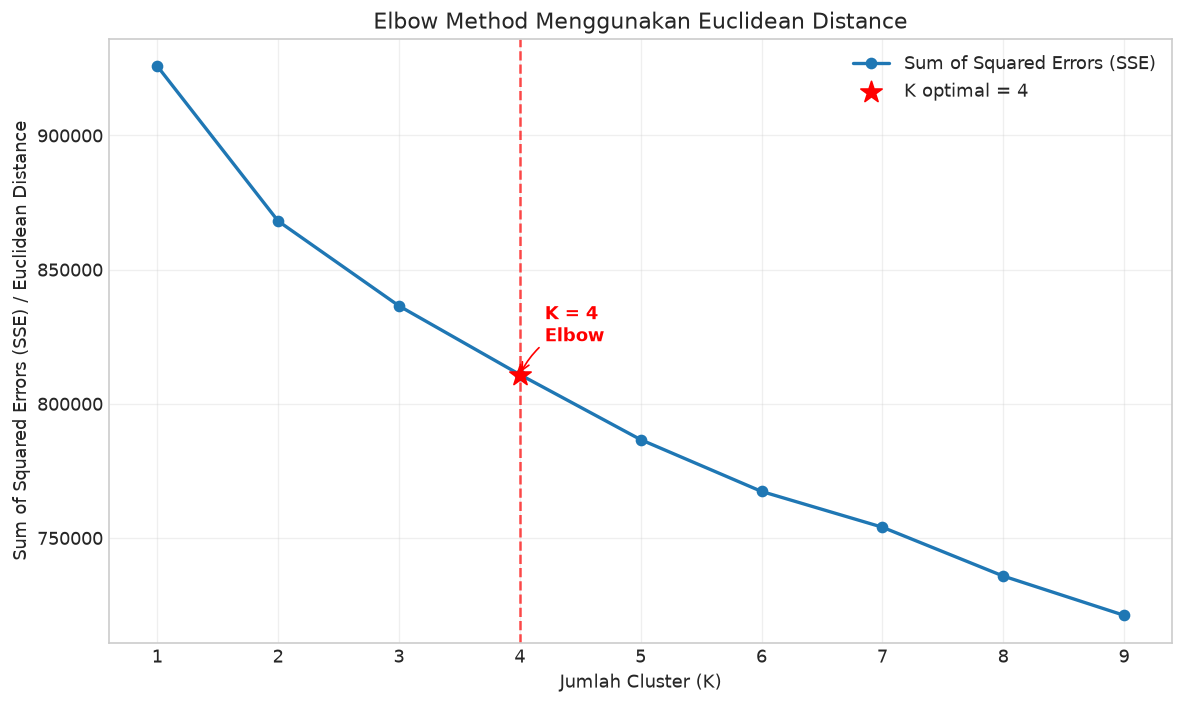

Menghitung Silhouette Score...


Untuk k=2, Silhouette Score = 0.3323


Untuk k=3, Silhouette Score = 0.0648


Untuk k=4, Silhouette Score = 0.0785


Untuk k=5, Silhouette Score = 0.0611


Untuk k=6, Silhouette Score = 0.0682


Untuk k=7, Silhouette Score = 0.0726


Untuk k=8, Silhouette Score = 0.0747


Untuk k=9, Silhouette Score = 0.0387


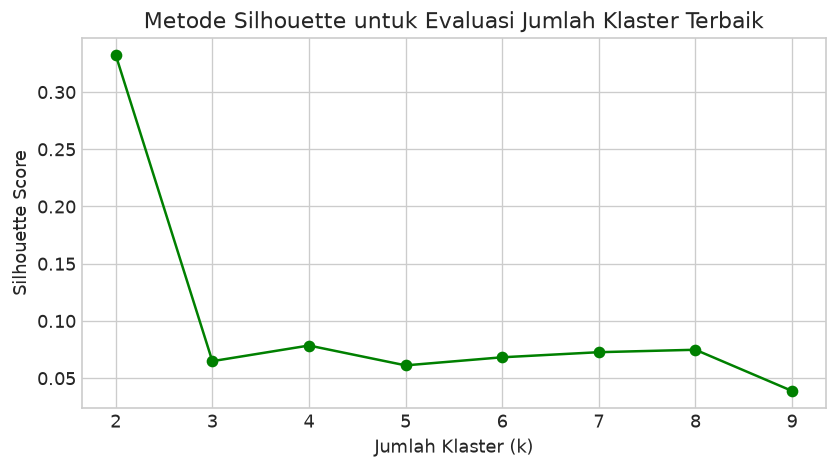

K= 2 | Total Manhattan=   342517.12 | Silhouette(L1)=0.1001 | iter=9


K= 3 | Total Manhattan=   325824.02 | Silhouette(L1)=0.1174 | iter=12


K= 4 | Total Manhattan=   315416.00 | Silhouette(L1)=0.1130 | iter=27


K= 5 | Total Manhattan=   305458.54 | Silhouette(L1)=0.0505 | iter=31


K= 6 | Total Manhattan=   298057.24 | Silhouette(L1)=0.0700 | iter=16


K= 7 | Total Manhattan=   289579.77 | Silhouette(L1)=0.0759 | iter=13


K= 8 | Total Manhattan=   287255.61 | Silhouette(L1)=0.0657 | iter=17


K= 9 | Total Manhattan=   284391.07 | Silhouette(L1)=0.0696 | iter=19


K=10 | Total Manhattan=   280960.09 | Silhouette(L1)=0.0772 | iter=20

Cek monoton turun: True
K optimal (Elbow)      : 7
K terbaik (Silhouette) : 3


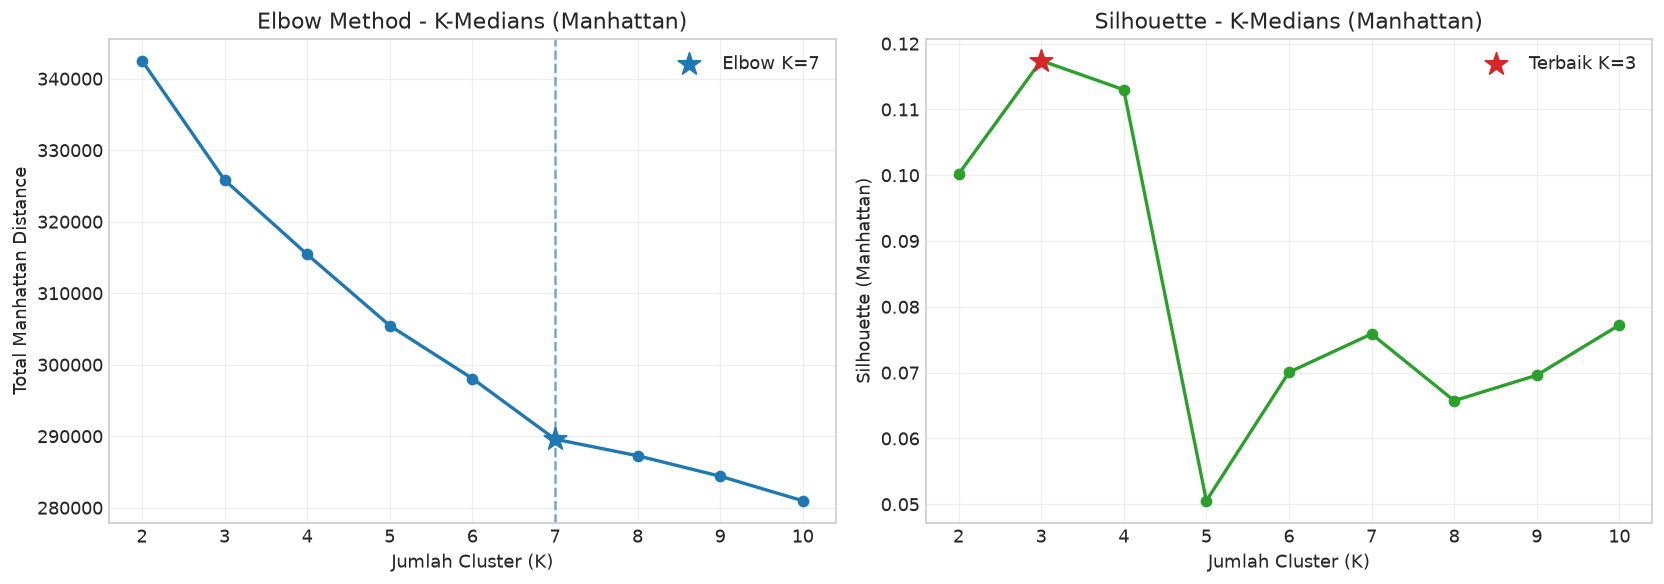

Menjalankan K-Means untuk K=2...
K=2 | Mean Cosine Similarity=0.2654
Menjalankan K-Means untuk K=3...


K=3 | Mean Cosine Similarity=0.3461
Menjalankan K-Means untuk K=4...
K=4 | Mean Cosine Similarity=0.3912
Menjalankan K-Means untuk K=5...


K=5 | Mean Cosine Similarity=0.4255
Menjalankan K-Means untuk K=6...


K=6 | Mean Cosine Similarity=0.4482
Menjalankan K-Means untuk K=7...


K=7 | Mean Cosine Similarity=0.4630
Menjalankan K-Means untuk K=8...


K=8 | Mean Cosine Similarity=0.4763
Menjalankan K-Means untuk K=9...


K=9 | Mean Cosine Similarity=0.4871
Menjalankan K-Means untuk K=10...


K=10 | Mean Cosine Similarity=0.4991


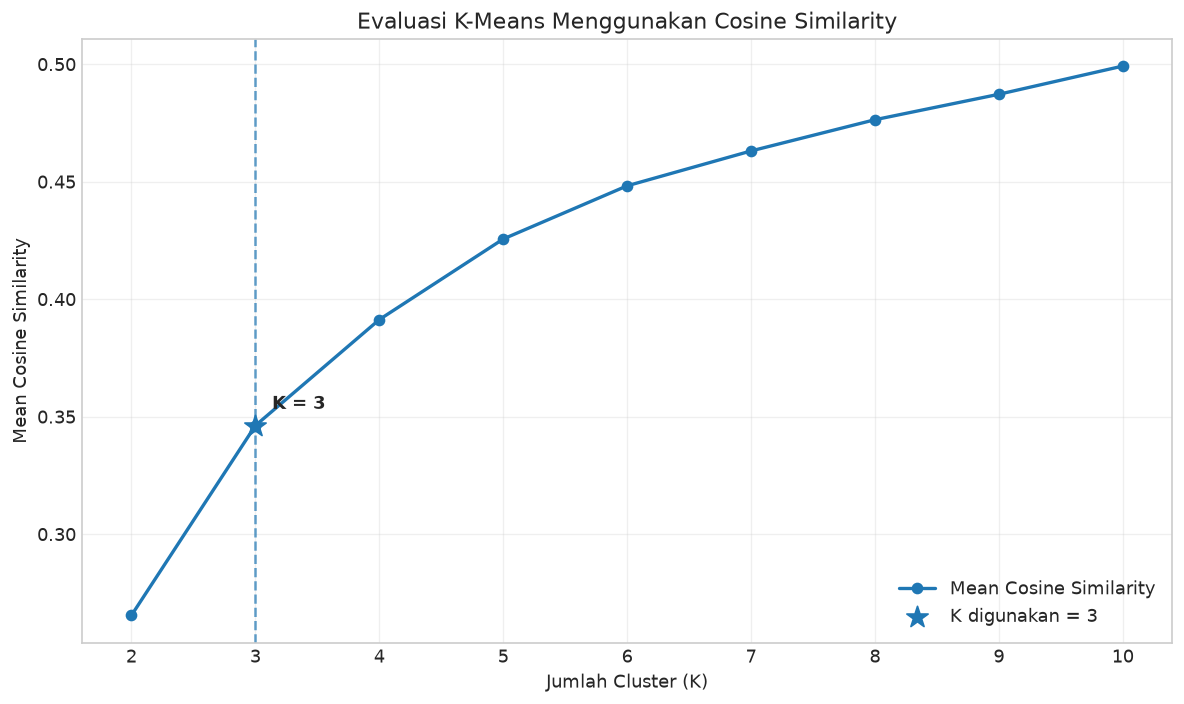

In [ ]:
# =======================================================================
# 4. EVALUASI JUMLAH KLASTER PADA TIGA METRIK
# =======================================================================
# 1. Menghitung SSE untuk K 1 hingga 9
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(X_scaled)
    sse.append(kmeanModel.inertia_)

# 2. Mencari K optimal dengan KneeLocator
kl = KneeLocator(K, sse, curve="convex", direction="decreasing")
optimal_k = kl.elbow
if optimal_k is None:
    # Jarak tegak lurus pada kurva yang dinormalisasi.
    x = np.asarray(list(K), dtype=float)
    y = np.asarray(sse, dtype=float)
    xn = (x - x.min()) / np.ptp(x)
    yn = (y - y.min()) / np.ptp(y) if np.ptp(y) > 0 else np.zeros_like(y)
    optimal_k = list(K)[int(np.argmax(np.abs(xn + yn - 1)))]
    print('KneeLocator tidak menemukan siku; digunakan estimasi geometris.')
optimal_k = int(optimal_k)
print('K yang dipilih (Elbow):', optimal_k)

# Mencari indeks dari optimal_k di dalam list K untuk mendapatkan nilai Y (SSE) yang tepat
optimal_index = list(K).index(optimal_k)

# 3. Visualisasi dengan gaya kustom
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    sse,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Sum of Squared Errors (SSE)"
)

if optimal_k is not None:
    # Titik K optimal
    plt.scatter(
        optimal_k,
        sse[optimal_index],
        s=180,
        color="red",
        marker="*",
        zorder=5,
        label=f"K optimal = {optimal_k}"
    )

    # Garis vertikal
    plt.axvline(
        optimal_k,
        color="red",
        linestyle="--",
        alpha=0.7
    )

    # Label Anotasi
    plt.annotate(
        f"K = {optimal_k}\nElbow",
        xy=(
            optimal_k,
            sse[optimal_index]
        ),
        xytext=(15, 20), # Disesuaikan sedikit agar teks tidak tertabrak garis
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red", connectionstyle="arc3,rad=.2")
    )

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE) / Euclidean Distance")
plt.title("Elbow Method Menggunakan Euclidean Distance")

plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

sil_scores = []
K_sil = range(2, 10) # Range k=2 hingga k=9

print("Menghitung Silhouette Score...")
for k in K_sil:
    # Inisialisasi dan latih model
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_sil.fit_predict(X_scaled)

    # Silhouette dihitung pada seluruh data.
    score = silhouette_score(X_scaled, labels_k)
    sil_scores.append(score)

    print(f"Untuk k={k}, Silhouette Score = {score:.4f}")

# Memvisualisasikan hasil
plt.figure(figsize=(8, 4))
plt.plot(K_sil, sil_scores, "go-")
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Metode Silhouette untuk Evaluasi Jumlah Klaster Terbaik")
plt.grid(True)
plt.show()

optimal_k_euclidean = optimal_k

K_range = list(range(2, 11))
costs, sils, models = [], [], {}

for k in K_range:
    labels_k, cent_k, cost_k, n_it = kmedians(X_scaled, k, n_init=10)

    # Silhouette dengan jarak Manhattan
    sil_k = silhouette_score(
        X_scaled, labels_k, metric="manhattan",
    )

    costs.append(cost_k); sils.append(sil_k); models[k] = (labels_k, cent_k)
    print(f"K={k:2d} | Total Manhattan={cost_k:12.2f} | Silhouette(L1)={sil_k:.4f} | iter={n_it}")

print("\nCek monoton turun:", all(np.diff(costs) <= 1e-6))

x = np.array(K_range, dtype=float)
y = np.array(costs, dtype=float)
xn = (x - x.min()) / (x.max() - x.min())
yn = (y - y.min()) / np.ptp(y) if np.ptp(y) > 0 else np.zeros_like(y)

# garis dari (0,1) ke (1,0): x + y - 1 = 0
dist_line = np.abs(xn + yn - 1) / np.sqrt(2)

optimal_k = K_range[int(np.argmax(dist_line))]
best_sil_k = K_range[int(np.argmax(sils))]
print("K optimal (Elbow)      :", optimal_k)
print("K terbaik (Silhouette) :", best_sil_k)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, costs, marker="o", lw=2)
ax[0].scatter(optimal_k, costs[K_range.index(optimal_k)], s=200, marker="*", zorder=5,
              label=f"Elbow K={optimal_k}")
ax[0].axvline(optimal_k, ls="--", alpha=.6)
ax[0].set(xlabel="Jumlah Cluster (K)", ylabel="Total Manhattan Distance",
          title="Elbow Method - K-Medians (Manhattan)")
ax[0].set_xticks(K_range); ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(K_range, sils, marker="o", lw=2, color="tab:green")
ax[1].scatter(best_sil_k, max(sils), s=200, marker="*", zorder=5, color="tab:red",
              label=f"Terbaik K={best_sil_k}")
ax[1].set(xlabel="Jumlah Cluster (K)", ylabel="Silhouette (Manhattan)",
          title="Silhouette - K-Medians (Manhattan)")
ax[1].set_xticks(K_range); ax[1].grid(alpha=.3); ax[1].legend()

plt.tight_layout(); plt.show()

optimal_k_manhattan = optimal_k


K_range = range(2, 11)

cosine_similarity_scores = []

for k in K_range:

    print(f"Menjalankan K-Means untuk K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_k = kmeans.fit_predict(X_cosine)

    # Cosine similarity data terhadap seluruh centroid
    similarities = cosine_similarity(
        X_cosine,
        kmeans.cluster_centers_
    )

    # Ambil similarity terhadap centroid cluster masing-masing data
    assigned_similarity = similarities[
        np.arange(len(X_cosine)),
        labels_k
    ]

    # Rata-rata similarity
    mean_similarity = assigned_similarity.mean()

    cosine_similarity_scores.append(
        mean_similarity
    )

    print(
        f"K={k} | "
        f"Mean Cosine Similarity={mean_similarity:.4f}"
    )

K_OPTIMAL = 3
optimal_k_cosine = K_OPTIMAL
optimal_index = list(K_range).index(optimal_k_cosine)

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2,
    label="Mean Cosine Similarity"
)

plt.scatter(
    optimal_k_cosine,
    cosine_similarity_scores[optimal_index],
    s=180,
    marker="*",
    zorder=5,
    label=f"K digunakan = {optimal_k_cosine}"
)

plt.axvline(
    optimal_k_cosine,
    linestyle="--",
    alpha=0.7
)

plt.annotate(
    f"K = {optimal_k_cosine}",
    xy=(
        optimal_k_cosine,
        cosine_similarity_scores[optimal_index]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontweight="bold"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Evaluasi K-Means Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING & TABEL PERBANDINGAN
# =======================================================================
# Euclidean: jumlah klaster dari Elbow SSE.
def _fit_euclid():
    return KMeans(n_clusters=optimal_k_euclidean, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)

model_euclid, ukur_euclid = ukur_kinerja(_fit_euclid)
y_kmeans = model_euclid.labels_.copy()
hasil_euclid = {
    'nama': 'K-Means\n(Euclidean)', 'K': optimal_k_euclidean,
    'labels': y_kmeans, 'centroids': model_euclid.cluster_centers_.copy(),
    'data': X_scaled, 'total_cluster': len(np.unique(y_kmeans)),
    'silhouette_native': silhouette_score(X_scaled, y_kmeans, metric='euclidean'),
    **ukur_euclid,
}

# Manhattan: jumlah klaster dari Elbow SAE; n_init final = 20.
def _fit_manhattan():
    return kmedians(X_scaled, optimal_k_manhattan, n_init=20)

(labels_manhattan, centroids_manhattan, final_cost, n_iter), ukur_manhattan = ukur_kinerja(_fit_manhattan)
hasil_manhattan = {
    'nama': 'K-Medians\n(Manhattan)', 'K': optimal_k_manhattan,
    'labels': labels_manhattan, 'centroids': centroids_manhattan,
    'data': X_scaled, 'total_cluster': len(np.unique(labels_manhattan)),
    'silhouette_native': silhouette_score(X_scaled, labels_manhattan, metric='manhattan'),
    **ukur_manhattan,
}

# Cosine: jumlah klaster final = 3 pada data setelah normalisasi L2.
def _fit_cosine():
    return KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10).fit(X_cosine)

model_cosine, ukur_cosine = ukur_kinerja(_fit_cosine)
labels_cosine = model_cosine.labels_.copy()
hasil_cosine = {
    'nama': 'K-Means\n(Cosine)', 'K': K_OPTIMAL,
    'labels': labels_cosine, 'centroids': model_cosine.cluster_centers_.copy(),
    'data': X_cosine, 'total_cluster': len(np.unique(labels_cosine)),
    'silhouette_native': silhouette_score(X_cosine, labels_cosine, metric='cosine'),
    **ukur_cosine,
}

hasil = [hasil_euclid, hasil_manhattan, hasil_cosine]
y_true = df["status"].values

rows = []
for h in hasil:
    rows.append({
        "Algoritma": h["nama"].replace("\n", " "),
        "K": h["K"],
        "Silhouette (metrik masing-masing)": h["silhouette_native"],
        "Silhouette (Euclidean seragam)": silhouette_score(X_scaled, h["labels"], metric="euclidean"),
        "ARI": adjusted_rand_score(y_true, h["labels"]),
        "NMI": normalized_mutual_info_score(y_true, h["labels"]),
    })

df_banding = pd.DataFrame(rows).set_index("Algoritma")
display(df_banding.round(4))

# Tabel ringkasan kinerja
df_kinerja = pd.DataFrame([{
    "Algoritma": h["nama"].replace("\n", " "),
    "Total Cluster": h["total_cluster"],
    "Silhouette Score": h["silhouette_native"],
    "Waktu Komputasi (detik)": h["waktu_detik"],
    "Memori Puncak RSS (MiB)": h["mem_rss_mib"],
    "Memori Puncak tracemalloc (MiB)": h["mem_tracemalloc_mib"],
} for h in hasil]).set_index("Algoritma")

display(df_kinerja.round(4))


,K,Silhouette (metrik masing-masing),Silhouette (Euclidean seragam),ARI,NMI
Algoritma,,,,,
K-Means (Euclidean),4,0.0785,0.0785,0.3990,0.3557
K-Medians (Manhattan),7,0.0759,0.0167,0.1515,0.2283
K-Means (Cosine),3,0.1286,0.0046,0.3339,0.2831


,Total Cluster,Silhouette Score,Waktu Komputasi (detik),Memori Puncak RSS (MiB),Memori Puncak tracemalloc (MiB)
Algoritma,,,,,
K-Means (Euclidean),4,0.0785,0.1174,0.0312,14.1956
K-Medians (Manhattan),7,0.0759,3.0435,0.0312,11.0247
K-Means (Cosine),3,0.1286,0.1245,0.0312,14.1956


Explained variance PCA StandardScaler: 15.51%
Explained variance PCA Cosine (L2): 17.76%


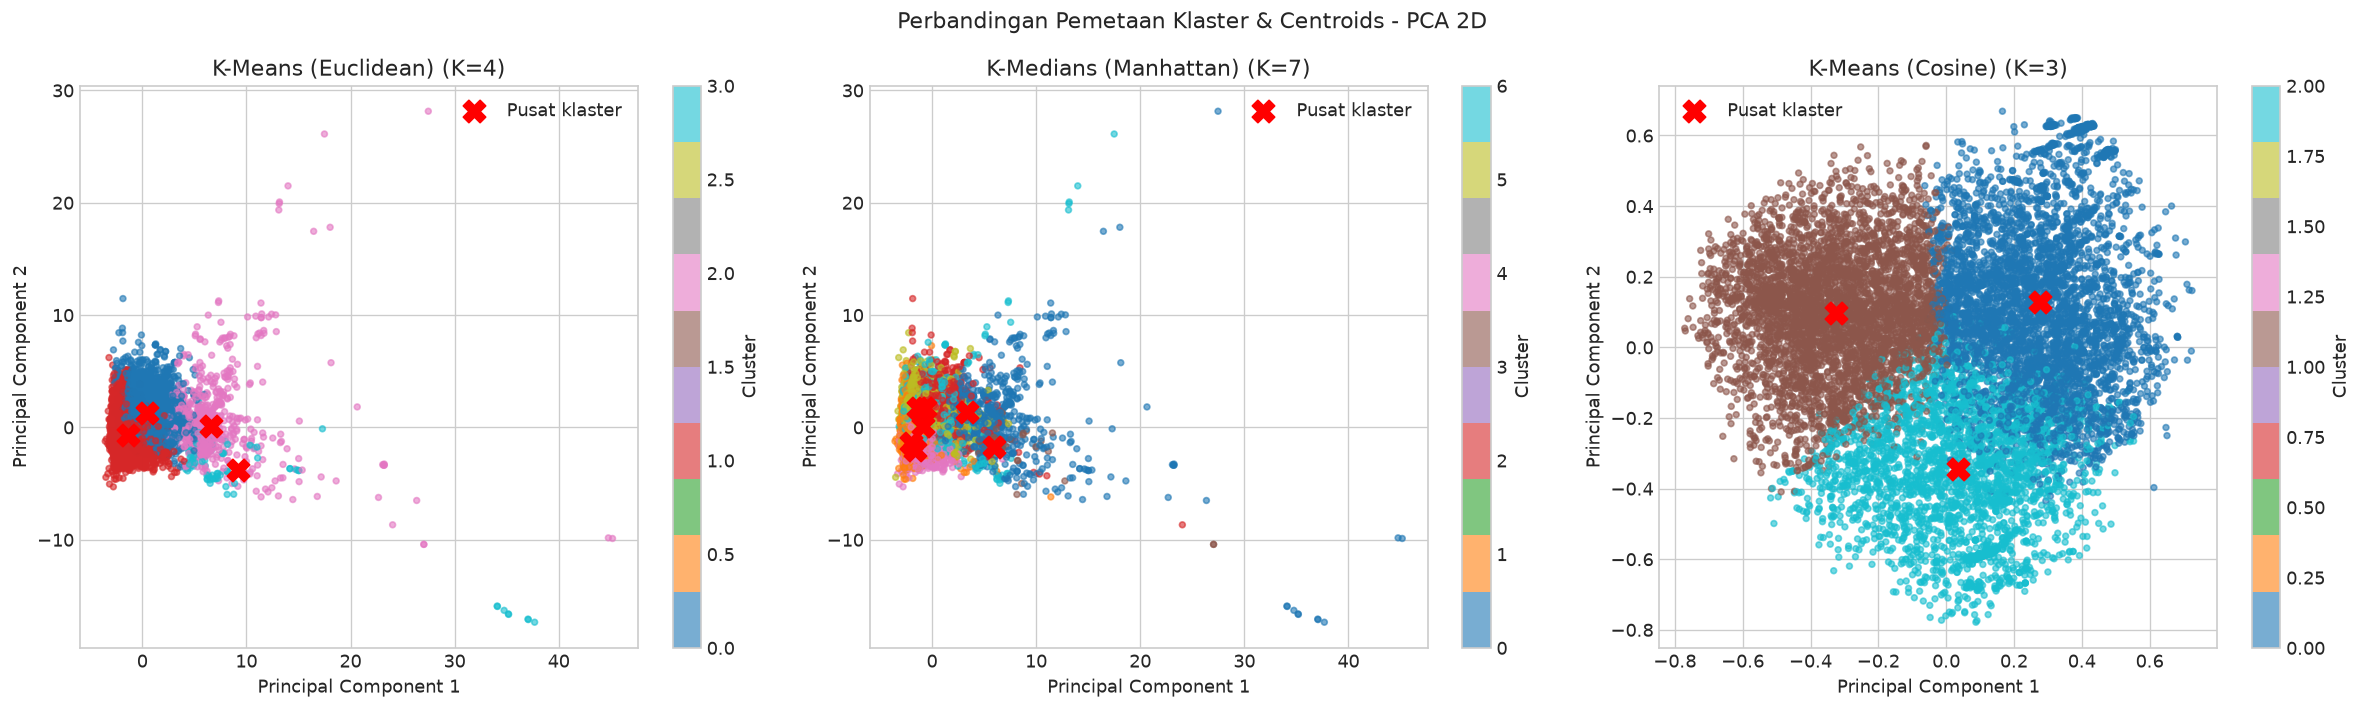

In [ ]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca_std = PCA(n_components=2, svd_solver='full', random_state=RANDOM_STATE)
X_pca_std = pca_std.fit_transform(X_scaled)
pca_cosine = PCA(n_components=2, svd_solver='full', random_state=RANDOM_STATE)
X_pca_cosine = pca_cosine.fit_transform(X_cosine)
print(f'Explained variance PCA StandardScaler: {pca_std.explained_variance_ratio_.sum():.2%}')
print(f'Explained variance PCA Cosine (L2): {pca_cosine.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, h, projection, pca_model in zip(
    axes, hasil, [X_pca_std, X_pca_std, X_pca_cosine], [pca_std, pca_std, pca_cosine]
):
    points = ax.scatter(projection[:, 0], projection[:, 1], c=h['labels'], cmap='tab10', s=12, alpha=0.6)
    centers_2d = pca_model.transform(h['centroids'])
    ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='X', s=180, label='Pusat klaster')
    ax.set_title(f"{h['nama'].replace(chr(10), ' ')} (K={h['K']})")
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend()
    fig.colorbar(points, ax=ax, label='Cluster')
plt.suptitle('Perbandingan Pemetaan Klaster & Centroids - PCA 2D')
plt.tight_layout()
plt.show()


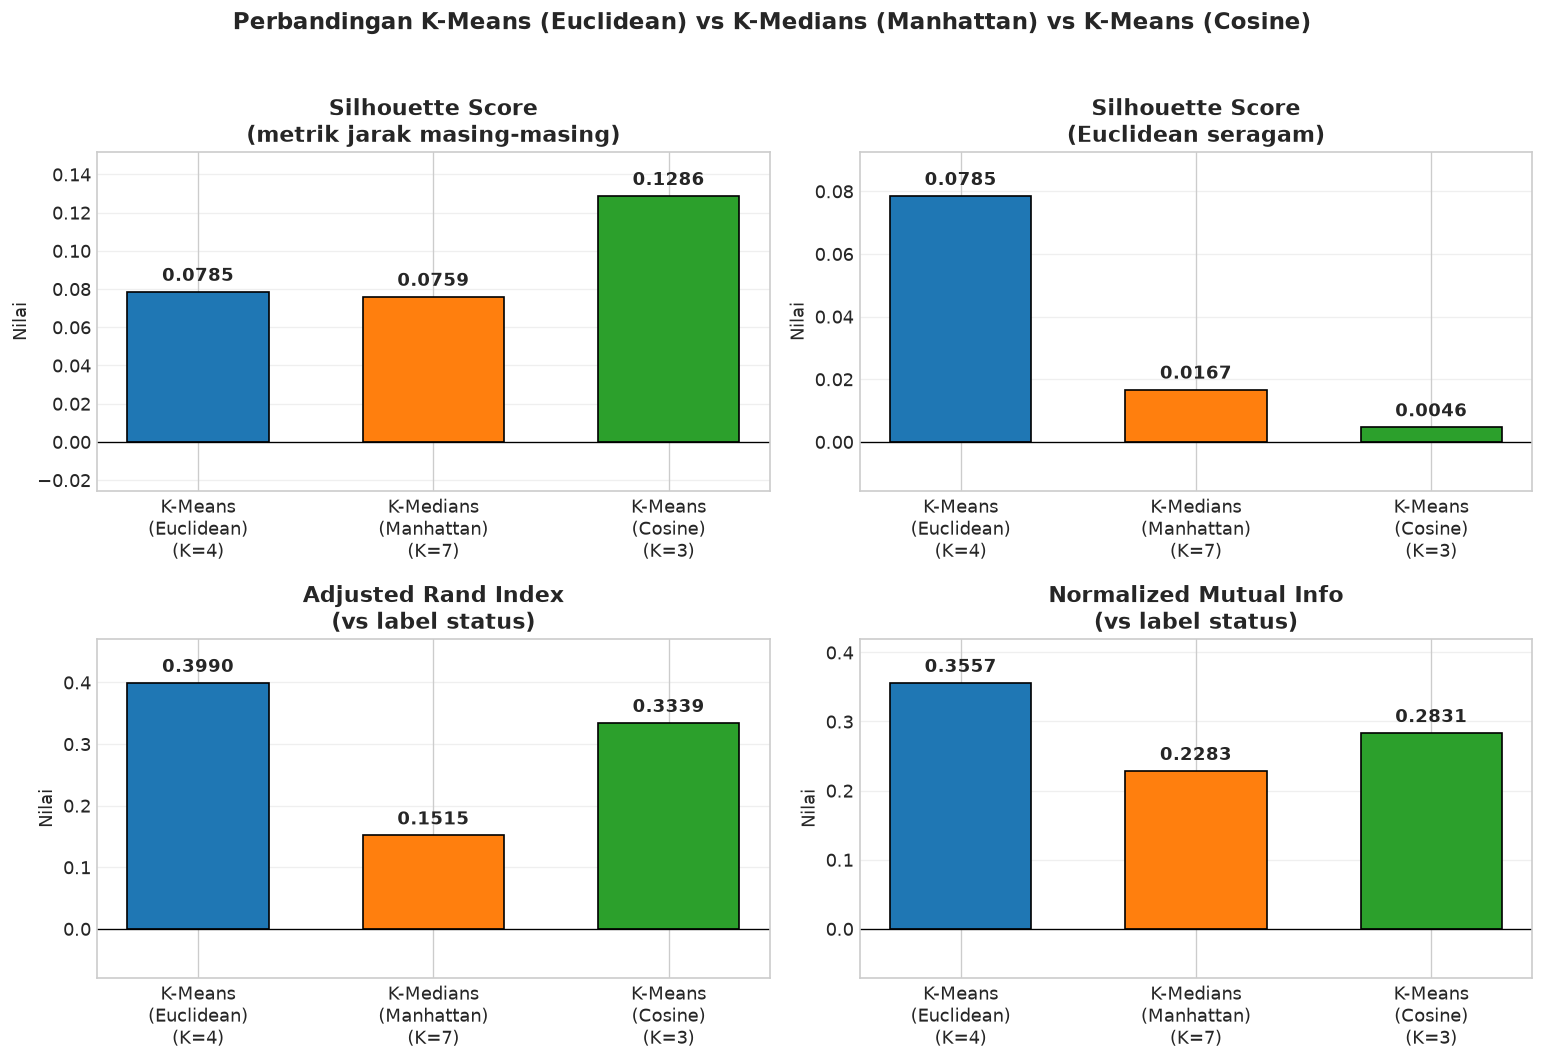

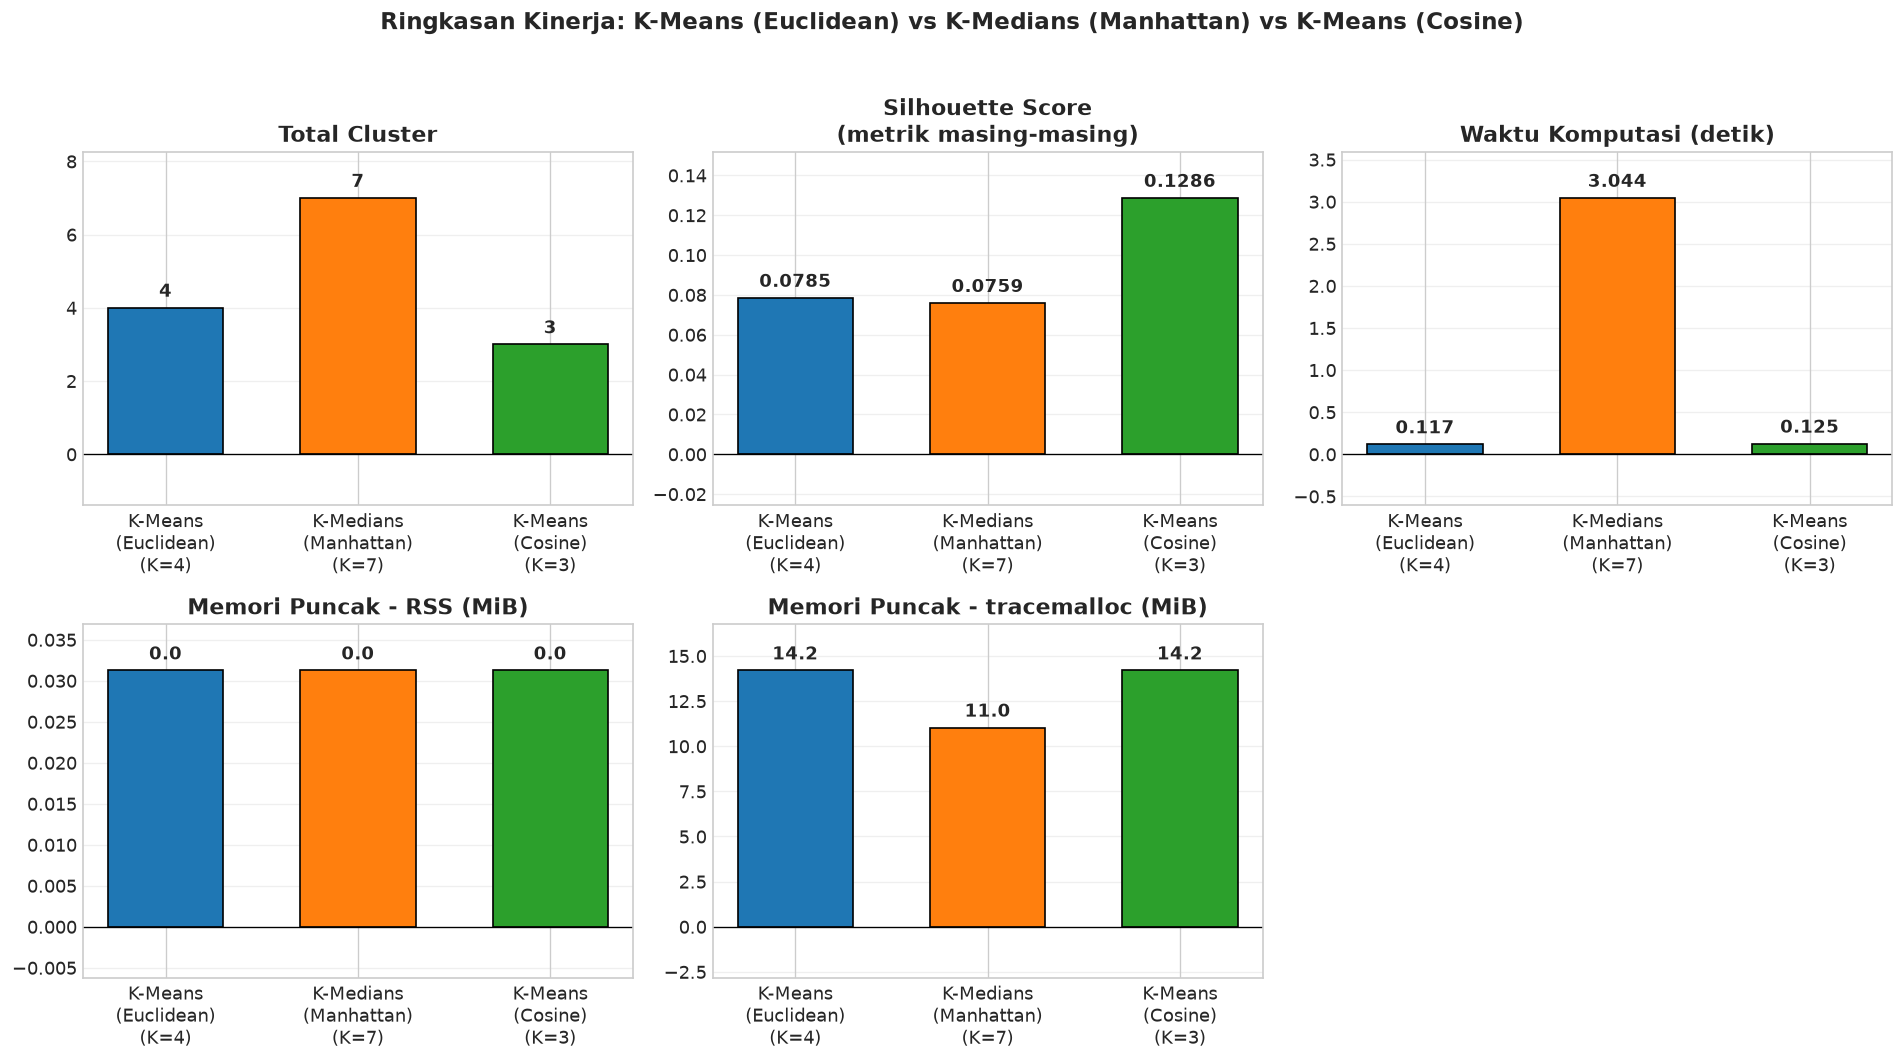

In [ ]:
# =======================================================================
# 7. DIAGRAM BATANG PERBANDINGAN EVALUASI & KINERJA
# =======================================================================
nama = [h["nama"] + f"\n(K={h['K']})" for h in hasil]
warna = ["tab:blue", "tab:orange", "tab:green"]

metrik = [
    ("Silhouette (metrik masing-masing)", "Silhouette Score\n(metrik jarak masing-masing)"),
    ("Silhouette (Euclidean seragam)",    "Silhouette Score\n(Euclidean seragam)"),
    ("ARI",                               "Adjusted Rand Index\n(vs label status)"),
    ("NMI",                               "Normalized Mutual Info\n(vs label status)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (kolom, judul) in zip(axes.ravel(), metrik):
    nilai = df_banding[kolom].values
    bars = ax.bar(nama, nilai, color=warna, edgecolor="black", width=0.6)
    ax.set_title(judul, fontweight="bold")
    ax.set_ylabel("Nilai")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)

    batas = max(abs(nilai).max(), 1e-9)
    ax.set_ylim(min(0, nilai.min()) - 0.20 * batas, nilai.max() + 0.18 * batas)
    for b, v in zip(bars, nilai):
        ax.annotate(f"{v:.4f}", (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom" if v >= 0 else "top",
                    xytext=(0, 4 if v >= 0 else -4), textcoords="offset points",
                    fontweight="bold")

fig.suptitle("Perbandingan K-Means (Euclidean) vs K-Medians (Manhattan) vs K-Means (Cosine)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Diagram batang: total cluster, silhouette, waktu, dan memori
nama = [h["nama"] + f"\n(K={h['K']})" for h in hasil]
warna = ["tab:blue", "tab:orange", "tab:green"]

panel = [
    ("Total Cluster",                   "Total Cluster",                         "{:.0f}"),
    ("Silhouette Score",                "Silhouette Score\n(metrik masing-masing)", "{:.4f}"),
    ("Waktu Komputasi (detik)",         "Waktu Komputasi (detik)",               "{:.3f}"),
    ("Memori Puncak RSS (MiB)",         "Memori Puncak - RSS (MiB)",             "{:.1f}"),
    ("Memori Puncak tracemalloc (MiB)", "Memori Puncak - tracemalloc (MiB)",     "{:.1f}"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (kolom, judul, fmt) in zip(axes.ravel(), panel):
    nilai = df_kinerja[kolom].values
    bars = ax.bar(nama, nilai, color=warna, edgecolor="black", width=0.6)
    ax.set_title(judul, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)
    batas = max(abs(nilai).max(), 1e-9)
    ax.set_ylim(min(0, nilai.min()) - 0.20 * batas, nilai.max() + 0.18 * batas)
    for b, v in zip(bars, nilai):
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom" if v >= 0 else "top",
                    xytext=(0, 4 if v >= 0 else -4), textcoords="offset points",
                    fontweight="bold")
axes.ravel()[-1].axis("off")

fig.suptitle("Ringkasan Kinerja: K-Means (Euclidean) vs K-Medians (Manhattan) vs K-Means (Cosine)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# =======================================================================
# 8. INTERPRETASI HASIL PERBANDINGAN
# =======================================================================
print('INTERPRETASI HASIL PERBANDINGAN')
for metric in ['Silhouette (Euclidean seragam)', 'ARI', 'NMI']:
    best = df_banding[metric].idxmax()
    print(f'{metric} tertinggi: {best} ({df_banding.loc[best, metric]:.4f})')
fastest = df_kinerja['Waktu Komputasi (detik)'].idxmin()
print(f'Waktu fit terendah pada eksekusi ini: {fastest}')
print('Silhouette per metrik menggambarkan geometri masing-masing; evaluasi Euclidean seragam memakai X_scaled.')
print('ARI dan NMI membandingkan hasil klaster dengan status asli; status tidak masuk sebagai fitur.')
print('PCA hanya digunakan untuk visualisasi. Waktu dan memori dipengaruhi lingkungan eksekusi.')


INTERPRETASI HASIL PERBANDINGAN
Silhouette (Euclidean seragam) tertinggi: K-Means (Euclidean) (0.0785)
ARI tertinggi: K-Means (Euclidean) (0.3990)
NMI tertinggi: K-Means (Euclidean) (0.3557)
Waktu fit terendah pada eksekusi ini: K-Means (Euclidean)
Silhouette per metrik menggambarkan geometri masing-masing; evaluasi Euclidean seragam memakai X_scaled.
ARI dan NMI membandingkan hasil klaster dengan status asli; status tidak masuk sebagai fitur.
PCA hanya digunakan untuk visualisasi. Waktu dan memori dipengaruhi lingkungan eksekusi.
